# Week 01

MSSV: 22302421

Name: Nguyễn Phúc Minh Châu

In [1]:
%pip install roboticstoolbox-python

  Using cached roboticstoolbox_python-1.1.1.tar.gz (1.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached spatialmath_python-1.1.16-py3-none-any.whl.metadata (18 kB)
  Using cached spatialgeometry-1.1.0.tar.gz (1.0 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pgraph_python-0.6.3-py3-none-any.whl.metadata (7.5 kB)
  Using cached ansitable-0.11.5-py3-none-any.whl.metadata (28 kB)
  Using cached swift-sim-1.1.0.tar.gz (1.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached rtb_data-1.0.1-py3-none-any.whl
  Using cached progress-1.6.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached pre_commit-4.6.0-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached websockets-16.0-cp314-cp31

### Lab Exercise 1: 2D Rotation Matrix

In [2]:
from spatialmath import SO2

# Create a rotation of 45 degrees
R = SO2(45, unit='deg')
print(R)

# Access the underlying numpy arrayprint(R.A)
print(R.A)

# Verify orthogonality: R * R.T should be identity
print(R * R.inv())

   0.7071   -0.7071    
   0.7071    0.7071    

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
   1         0         
   0         1         



### Lab Exercise 2: 3D Rotation Matrix

In [3]:
from spatialmath import SO3
# Individual axis rotations
Rx = SO3.Rx(30, unit='deg')
Ry = SO3.Ry(45, unit='deg')

# Compose: first rotate around X, then Y
R = Rx * Ry

print(R)
print("det(R) =", R.det()) # Should be 1.0
print("R*R.T =", (R * R.inv()).A)  # Should be Identity

   0.7071    0         0.7071    
   0.3536    0.866    -0.3536    
  -0.6124    0.5       0.6124    

det(R) = 0.9999999999999999
R*R.T = [[ 1.00000000e+00 -1.11855716e-17  2.68691693e-17]
 [-1.11855716e-17  1.00000000e+00  4.20765666e-17]
 [ 2.68691693e-17  4.20765666e-17  1.00000000e+00]]


### Lab Exercise 3: SE(2) Transformation

   0.7071   -0.7071    2         
   0.7071    0.7071    3         
   0         0         1         

Translation: [2. 3.]
Rotation: 0.7853981633974483


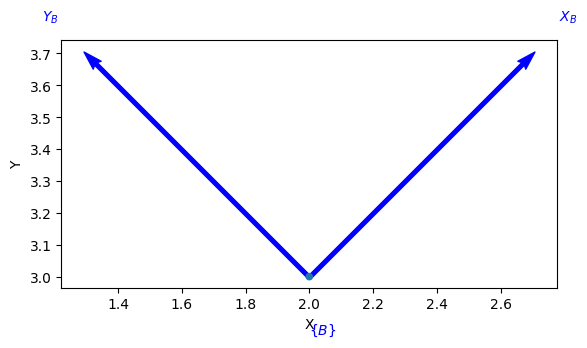

In [4]:
from spatialmath import SE2

# Translate by (2, 3) and rotate by 45 degrees
T = SE2(2, 3, 45, unit='deg')
print(T)
print("Translation:", T.t)  # [2, 3]
print("Rotation:", T.theta()) # 45 degrees

# Visualize (if matplotlib available)
T.plot(frame='B', color='blue')

### Lab Exercise 4: SE(3) Pose

In [5]:
from spatialmath import SE3

# Translate to (1, 2, 3), then rotate 90° around Z
T = SE3(1, 2, 3) * SE3.Rz(90, unit='deg')

print(T)
print("Position:", T.t)  # [1, 2, 3]
print("Rotation matrix:\n", T.R)

# Decompose the rotation to Euler angles
print("RPY angles:", T.rpy(unit='deg'))

   0        -1         0         1         
   1         0         0         2         
   0         0         1         3         
   0         0         0         1         

Position: [1. 2. 3.]
Rotation matrix:
 [[ 6.123234e-17 -1.000000e+00  0.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]
RPY angles: [ 0. -0. 90.]


### Lab Exercise 5: Transforming a Point

In [6]:
from spatialmath import SE3

# Create a complex transformation
T = SE3(2, 3, 4) * SE3.Rx(45, unit='deg')
 
# Compute the inverse
T_inv = T.inv()

# Verify: T * T_inv should equal Identity
result = T * T_inv
print("T * T_inv:\n", result)  # Should be Identity 4x4

# Direct computation
print("T_inv translation:", T_inv.t)
print("T_inv rotation:\n", T_inv.R)

T * T_inv:
    1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         

T_inv translation: [-2.         -4.94974747 -0.70710678]
T_inv rotation:
 [[ 1.          0.          0.        ]
 [ 0.          0.70710678  0.70710678]
 [ 0.         -0.70710678  0.70710678]]


### Lab Exercise 7: Euler Angles (RPY)

In [7]:
from spatialmath import SO3

# Create rotation from RPY angles
R = SO3.RPY([30, 45, 60], unit='deg')
print("Rotation matrix:\n", R)

# Extract RPY angles back from matrix
angles = R.rpy(unit='deg')
print("Extracted RPY:", angles)  # Should be [30, 45, 60]

# Verify round-trip consistency
print("Round-trip error:", angles - [30, 45, 60])

Rotation matrix:
    0.3536   -0.5732    0.7392    
   0.6124    0.7392    0.2803    
  -0.7071    0.3536    0.6124    

Extracted RPY: [30. 45. 60.]
Round-trip error: [-3.55271368e-15 -7.10542736e-15 -7.10542736e-15]


### Lab Exercise 8: Quaternions

In [8]:
from spatialmath import UnitQuaternion

# Create quaternion for 90° rotation around Z
q = UnitQuaternion.Rz(90, unit='deg')
print("Quaternion:", q)
print("w:", q.s, " xyz:", q.v)

# Convert to rotation matrix
R = q.SO3()
print("Rotation matrix:\n", R)

# Quaternion multiplication (composition)
q2 = UnitQuaternion.Rx(45, unit='deg')
q_combined = q * q2
print("Combined:", q_combined)

Quaternion:  0.7071 <<  0.0000,  0.0000,  0.7071 >>
w: 0.7071067811865476  xyz: [0.         0.         0.70710678]
Rotation matrix:
    0        -1         0         
   1         0         0         
   0         0         1         

Combined:  0.6533 <<  0.2706,  0.2706,  0.6533 >>


### Lab Exercise 9: Visualizing Transformations

/tmp/ipykernel_137709/3347012023.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


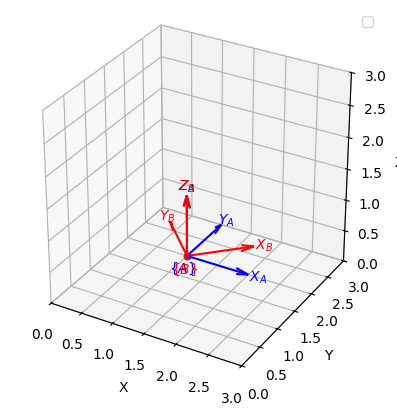

In [8]:
from spatialmath import SE3
from spatialmath.base import trplot
import matplotlib.pyplot as plt

# Create two frames
T1 = SE3(1, 2, 0)
T2 = T1 * SE3.Rz(45, unit='deg')

#Plot both frames
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trplot(T1.A, ax=ax, label='T1', color='blue', dims=[0,3,0,3,0,3], frame='A') 
trplot(T2.A, ax=ax, label='T2', color='red', frame='B') #A is the underlying 4x4 matrix
ax.legend()
plt.show()

### Mini Project: Robot in 3D Space

/tmp/ipykernel_137709/297813680.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


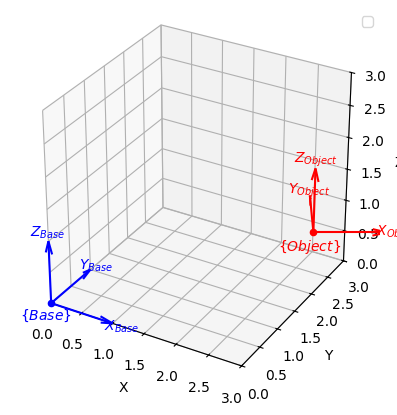

In [9]:
from spatialmath import SE3

#Create the robot base frame
T_base = SE3(0, 0, 0)

#Define an Object Frame
T_obj = SE3(3,2,1) * SE3.Rz(30, unit='deg')

#Compute the transformation
T_rel = T_base.inv() * T_obj

#Visualize Both frames
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trplot(T_base.A, ax=ax, label='Base', color='blue', dims=[0,3,0,3,0,3], frame='Base') 
trplot(T_obj.A, ax=ax, label='Object', color='red', frame='Object') 
ax.legend()
plt.show()